In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

In [2]:
df = pd.read_csv('df_final_final.csv')


In [3]:
print("컬럼 목록:")
print(df.columns.tolist())

print("\n결측치:")
print(df.isnull().sum())

print("\n데이터 크기:")
print(f"행: {df.shape[0]}")
print(f"열: {df.shape[1]}")

컬럼 목록:
['name', 'title', 'context', 'date', 'year', 'full_text', 'cleaned_tokens', 'text_length', 'token_count', 'cleaned_tokens_no_name', 'token_count_no_name', 'cleaned_tokens_final', 'token_count_final', 'cleaned_tokens_analysis', 'token_count_analysis']

결측치:
name                       0
title                      0
context                    0
date                       0
year                       0
full_text                  0
cleaned_tokens             0
text_length                0
token_count                0
cleaned_tokens_no_name     0
token_count_no_name        0
cleaned_tokens_final       0
token_count_final          0
cleaned_tokens_analysis    0
token_count_analysis       0
dtype: int64

데이터 크기:
행: 5037
열: 15


In [4]:
#실제분석에 사용할 단어수
df['token_count_analysis'] = (
    df['cleaned_tokens_analysis']
    .astype(str)
    .str.split()
    .str.len()
)

df['token_count_analysis'].describe()

,token_count_analysis
count,5037.000000
mean,26.978559
std,10.661460
min,4.000000
25%,20.000000
50%,25.000000
75%,32.000000
max,80.000000


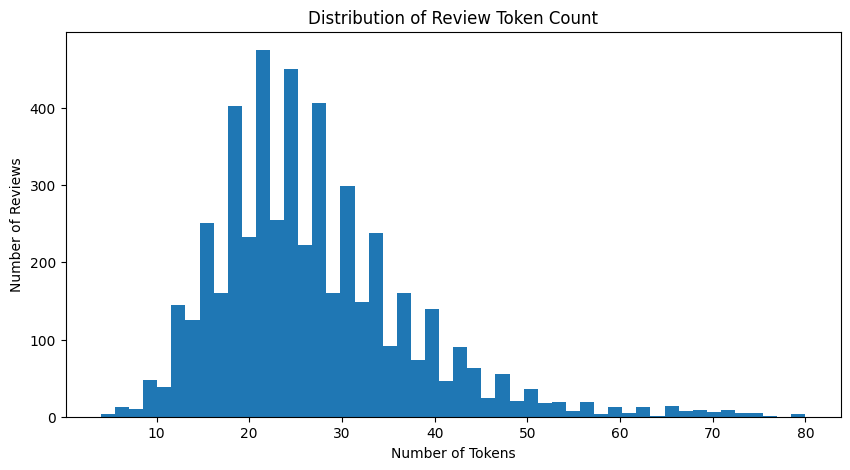

In [5]:
#리뷰길이 분포 시각화
plt.figure(figsize=(10, 5))

plt.hist(df['token_count_analysis'], bins=50)

plt.title('Distribution of Review Token Count')
plt.xlabel('Number of Tokens')
plt.ylabel('Number of Reviews')

plt.show()

In [6]:
#카페별 리뷰수
cafe_review_count = (
    df.groupby('name')
    .size()
    .sort_values(ascending=False)
)

cafe_review_count

,0
name,
오베르캄프,298
까페항상,297
메모러블모먼트,297
애크로매틱커피,296
카페 오텀,292
센서리티커피,256
스팀비,247
드리프트우드,236
카페담금,229


In [7]:
print(cafe_review_count.describe())

count     38.000000
mean     132.552632
std       90.195493
min       33.000000
25%       56.500000
50%       93.000000
75%      186.750000
max      298.000000
dtype: float64


In [8]:
# 나눔 고딕 폰트 설치
%cd /content
!wget https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = 'NanumGothic-Regular.ttf'       # 설치한 폰트 경로
fm.fontManager.addfont(font_path)   # 폰트 경로 추가

plt.rcParams['font.family'] = 'NanumGothic' # 사용 폰트 입력
plt.rcParams['axes.unicode_minus'] = False  # 음수 부호 사용

/content
--2026-09-09 00:52:12--  https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/google/fonts/main/ofl/nanumgothic/NanumGothic-Regular.ttf [following]
--2026-09-09 00:52:13--  https://raw.githubusercontent.com/google/fonts/main/ofl/nanumgothic/NanumGothic-Regular.ttf
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2054744 (2.0M) [application/octet-stream]
Saving to: ‘NanumGothic-Regular.ttf’

NanumGothic-Regular 100%[===================>]   1.96M  --.-KB/s    in 0.008s  

2026-09-09 00:52:13 (238 MB/s) - ‘NanumGoth

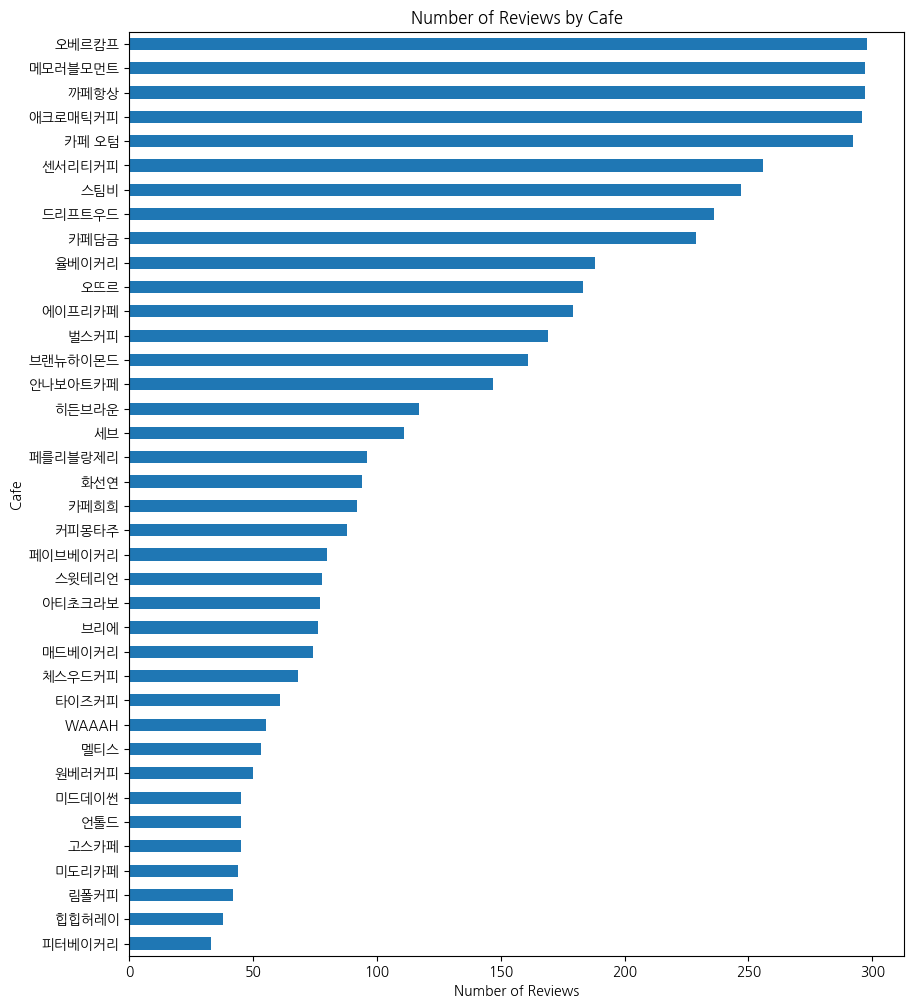

In [9]:
#카페별 리뷰수 시각화
plt.figure(figsize=(10, 12))

cafe_review_count.sort_values().plot(kind='barh')

plt.title('Number of Reviews by Cafe')
plt.xlabel('Number of Reviews')
plt.ylabel('Cafe')

plt.show()

In [14]:
#불용어 후보 추출
all_tokens = []

for text in df['cleaned_tokens_analysis'].dropna():

    tokens = str(text).split()
    all_tokens.extend(tokens)

In [15]:
#단어 빈도 계산
word_counts = Counter(all_tokens)

word_freq = pd.DataFrame(
    word_counts.most_common(),
    columns=['word', 'frequency']
)

word_freq.head(30)

,word,frequency
0,좋다,2044
1,디저트,1916
2,커피,1590
3,맛있다,1503
4,베이커리,1321
5,분위기,1080
6,빵집,847
7,에그타르트,844
8,메뉴,775
9,브런치,767


In [16]:
#상위단어 50개 확인
word_freq.head(50)

,word,frequency
0,좋다,2044
1,디저트,1916
2,커피,1590
3,맛있다,1503
4,베이커리,1321
5,분위기,1080
6,빵집,847
7,에그타르트,844
8,메뉴,775
9,브런치,767


In [19]:
#카페별 특정토큰 등장 여부 알아보기
cafe_count = df['name'].nunique()

word_cafe_count = {}

for cafe, group in df.groupby('name'):

    cafe_tokens = set(
        ' '.join(
            group['cleaned_tokens_analysis']
            .dropna()
            .astype(str)
        ).split()
    )

    for word in cafe_tokens:
        word_cafe_count[word] = word_cafe_count.get(word, 0) + 1

In [20]:
word_cafe_df = pd.DataFrame(
    list(word_cafe_count.items()),
    columns=['word', 'cafe_count']
)

In [21]:
word_analysis = word_freq.merge(
    word_cafe_df,
    on='word',
    how='left'
)

word_analysis['cafe_ratio'] = (
    word_analysis['cafe_count']
    / cafe_count
)

word_analysis.head(30)

,word,frequency,cafe_count,cafe_ratio
0,좋다,2044,38,1.000000
1,디저트,1916,38,1.000000
2,커피,1590,29,0.763158
3,맛있다,1503,38,1.000000
4,베이커리,1321,30,0.789474
5,분위기,1080,38,1.000000
6,빵집,847,26,0.684211
7,에그타르트,844,21,0.552632
8,메뉴,775,38,1.000000
9,브런치,767,30,0.789474
